# Donghang Zou's UChicago ADS Code Sample

### 1. Motivation and data

County social conditions help identify where chronic disease and unmet needs coincide. The larger project uses five CDC PLACES releases from 2021 to 2025 and CDC SVI 2020 and 2022. It cleans and stacks a county panel, correlates social and behavioral factors with diabetes and hypertension, and maps K-means profiles. This excerpt rebuilds the latest snapshot from raw CSVs; the full project is on GitHub, linked in the first code line. Food, housing, and transportation insecurity are the strongest diabetes correlates (r = 0.937, 0.921, and 0.914).

In [1]:
# GitHub: https://github.com/Booth-DH/Global_AI_Internship
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch, Patch
from matplotlib.path import Path as MplPath
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

ROOT = Path.cwd()
if ROOT.name == 'code_sample':
    ROOT = ROOT.parent
RAW = ROOT / 'data/raw'
OUT = ROOT / 'code_sample'
FIG = OUT / 'figures'
TABLE = OUT / 'tables'
yvars = ['DIABETES', 'BPHIGH']
factors = ('LPA OBESITY CSMOKING ACCESS2 '
    'DEPRESSION SLEEP BINGE RPL_THEMES '
    'RPL_THEME1 RPL_THEME2 RPL_THEME3 RPL_THEME4 '
    'FOODINSECU HOUSINSECU LACKTRPT LONELINESS'
).split()
sv = [f for f in factors if f.startswith('RPL')]

names = ('Inactivity|Obesity|Smoking|Uninsured|'
    'Depression|Short sleep|Binge drinking|'
    'Overall SVI|'
    'SVI: socioeconomic|SVI: household|SVI: minority|'
    'SVI: housing/transport|Food insecurity|'
    'Housing insecurity|Transport barriers|Loneliness'
).split('|')

Matplotlib is building the font cache; this may take a moment.


### 2. Loading and typing the data



In [2]:
# Keep leading zeros in county identifiers.
p = pd.read_csv(RAW / 'places_county_2025.csv',
    dtype={'locationid': 'string', 'year': 'int16',
           'data_value': 'float64'}, low_memory=False)
s = pd.read_csv(RAW / 'svi_county_2022.csv',
    dtype={'FIPS': 'string'}, usecols=['FIPS', *sv])
print(p[['locationid', 'data_value']].dtypes)
print('FIPS:', s.FIPS.dtype)

locationid    string[python]
data_value           float64
dtype: object
FIPS: string


### 3. Building the county snapshot

Age-adjusted measures form one row per county.

In [3]:
def prepare_county_snapshot(p, s):
    h = p.loc[(p.stateabbr != 'US') &
        (p.data_value_type ==
         'Age-adjusted prevalence')].copy()
    h['FIPS'] = h.locationid.str.zfill(5)
    h = h.sort_values('year').drop_duplicates(
        ['FIPS', 'measureid'], keep='last')
    w = h.pivot(index='FIPS', columns='measureid',
                values='data_value')
    # Sentinel values are missing, not low SVI.
    s = s.assign(FIPS=s.FIPS.str.zfill(5))
    s = s.replace(-999, np.nan).set_index('FIPS')
    # One-to-one keeps each county equally weighted.
    return w.join(s, validate='one_to_one').dropna(
        subset=[*yvars, 'RPL_THEMES'])

counties = prepare_county_snapshot(p, s)

### 4. Measuring associations

The table compares diabetes samples; the chart ranks all 16 factors for both outcomes.

In [4]:
def compare_correlations(data, y, factors,
                         sample_policy='pairwise'):
    v = data[[y, *factors]]
    # Common fixes geography; pairwise retains data.
    if sample_policy == 'common':
        v = v.dropna()
    rows = []
    for f in factors:
        pairs = v[[y, f]].dropna()
        rows.append((f, pairs[f].corr(pairs[y]),
                     len(pairs)))
    return pd.DataFrame(rows, columns=
        ['factor', 'r', 'n']).set_index('factor')

results = {y: compare_correlations(counties,
           y, factors) for y in yvars}
r = pd.DataFrame({y: t.r for y, t in results.items()})
shown = ['FOODINSECU','HOUSINSECU','LACKTRPT','LPA']
common = compare_correlations(counties, 'DIABETES',
                             shown, 'common')
paired = results['DIABETES'].loc[shown]
comparison = paired.join(common, lsuffix='_pair',
                          rsuffix='_common')
print(comparison.round(3).rename_axis(None))
comparison.to_csv(TABLE / 'correlation_summary.csv')

            r_pair  n_pair  r_common  n_common
FOODINSECU   0.937    2299     0.937      2299
HOUSINSECU   0.921    2299     0.921      2299
LACKTRPT     0.914    2299     0.914      2299
LPA          0.873    2956     0.850      2299


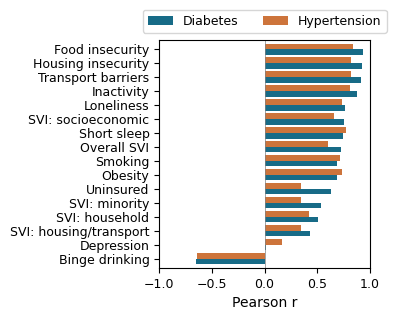

In [5]:
def plot_correlations(r):
    values = r.sort_values('DIABETES').rename(
        index=dict(zip(factors, names)),
        columns=dict(zip(yvars,
                        ['Diabetes', 'Hypertension'])))
    ax = values.plot.barh(figsize=(4, 3.35), width=.8,
        color=['#176b87', '#cd743b'], fontsize=9)
    ax.set(xlim=(-1, 1), xlabel='Pearson r', ylabel='')
    ax.axvline(0, color='grey', linewidth=.5)
    ax.legend(loc='upper center', fontsize=9,
              bbox_to_anchor=(.5, 1.16), ncol=2)
    plt.tight_layout()
    return ax.figure

fig = plot_correlations(r)
fig.savefig(FIG / 'fig_correlations.png', dpi=240)
plt.show()

### 5. Grouping and mapping counties

Mean absolute r selects factors; profile means are unweighted disease percentages and SVI ranks.

In [6]:
strength = r.abs().mean(axis=1).sort_values(ascending=False)
features = yvars + strength[strength >= .40].index.tolist()
complete = counties.dropna(subset=features).copy()
# Scale before K-means so units do not determine distance.
z = StandardScaler().fit_transform(complete[features])
model = KMeans(n_clusters=4, random_state=42, n_init=10).fit(z)
anchors = [features.index(f) for f in [*yvars, 'RPL_THEMES']]
order = np.argsort(model.cluster_centers_[:, anchors].mean(axis=1))
tiers = ['Low', 'Moderate', 'High', 'Highest']
labels = pd.Series(model.labels_, index=complete.index)
ordered_labels = labels.map(dict(zip(order, tiers)))
complete['tier'] = pd.Categorical(ordered_labels, categories=tiers, ordered=True)
summary = complete.groupby('tier', observed=True).agg(counties=('DIABETES', 'size'),
    diabetes=('DIABETES', 'mean'), hypertension=('BPHIGH', 'mean'), SVI=('RPL_THEMES', 'mean'))
print(f'{len(features)} features; {len(complete):,}/{len(counties):,} counties; '
      f'silhouette = {silhouette_score(z, model.labels_):.3f}')
print(summary.round(3).rename_axis(None))
summary.to_csv(TABLE / 'cluster_summary.csv')

16 features; 2,299/2,956 counties; silhouette = 0.203
          counties  diabetes  hypertension    SVI
Low            765     9.090        29.758  0.190
Moderate       788    10.765        33.306  0.456
High           508    12.555        36.755  0.754
Highest        238    15.786        42.943  0.895


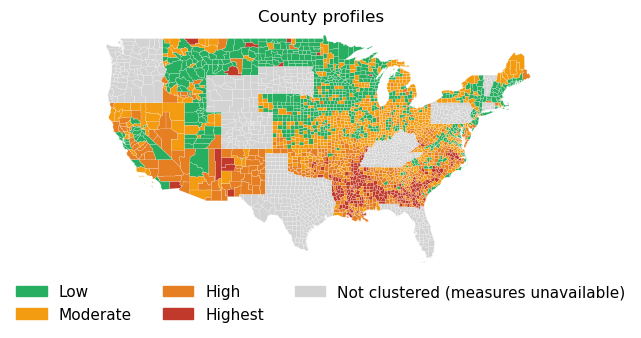

In [7]:
def plot_county_profiles(complete):
    colors = dict(zip(tiers, ['#27ae60', '#f39c12', '#e67e22', '#c0392b']))
    lookup = complete.tier.astype('string').map(colors).to_dict()
    geo = json.loads((ROOT / 'data/processed/us_counties.geojson').read_text())
    fig, ax = plt.subplots(figsize=(5.6, 3.1))
    for county in geo['features']:
        fips, g = county['id'], county['geometry']
        if fips[:2] in {'02', '15', '72'}:
            continue
        polygons = [g['coordinates']] if g['type'] == 'Polygon' else g['coordinates']
        for polygon in polygons:
            # Compound paths preserve islands and interior holes.
            rings = [MplPath(ring, closed=True) for ring in polygon]
            shape = MplPath.make_compound_path(*rings)
            patch = PathPatch(shape, facecolor=lookup.get(fips, '#d3d3d3'),
                              edgecolor='white', linewidth=.12)
            ax.add_patch(patch)
    ax.set(xlim=(-125, -66), ylim=(24, 50), aspect=1.25, title='County profiles')
    ax.axis('off')
    colors['Not clustered (measures unavailable)'] = '#d3d3d3'
    legend = [Patch(color=c, label=t) for t, c in colors.items()]
    ax.legend(handles=legend, loc='upper center', bbox_to_anchor=(.5, -.01),
              ncol=3, fontsize=11, frameon=False)
    return fig

fig = plot_county_profiles(complete)
fig.savefig(FIG / 'fig_risk_tier_map.png', dpi=240, bbox_inches='tight')
plt.show()

Grey includes 657 eligible counties in CO, FL, OR, SD, TN, TX, VT, WA, and WY missing social-needs measures, plus KY and PA, which lack diabetes and hypertension estimates. Nine CT planning regions lack cached geometry.

### 6. Findings and limits

The social-needs associations exceed physical inactivity, whose diabetes r changes from 0.873 on 2,956 counties to 0.850 on the 2,299-county common sample. Higher-burden profiles concentrate in the Deep South. These associations are not causal, and measurement years differ (PLACES 2022/2023 and SVI 2022). Profiles are descriptive and overlapping (silhouette 0.203).